
# Accidents routiers en Californie — où et quand intervenir ?

On travaille sur les données d'accidents routiers de Californie (1,74 million d'accidents entre 2016 et 2023) pour répondre à deux questions concrètes qu'un gestionnaire de voirie pourrait se poser.

**Question 1 — Sur quels tronçons faut-il agir en priorité ?**
On identifie les zones géographiques où les accidents sont à la fois fréquents et graves, et on produit une carte interactive avec les 50 zones les plus critiques.

**Question 2 — Les jours fériés et les grands événements changent-ils quelque chose ?**
On compare accidents et sévérité pendant Noël, Thanksgiving, le Super Bowl, le 4 juillet et Labor Day par rapport au reste de l'année.

> Ce notebook se concentre sur la Californie, mais la démarche est identique pour n'importe quel autre État : il suffit de changer le filtre `state == 'CA'`.

In [1]:
# Installer les dépendances manquantes (à exécuter une seule fois)
%pip install -q h3 folium branca scipy kagglehub pyspark

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\vince\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
os.environ["JDK_JAVA_OPTIONS"] = (
    "--add-opens=java.base/java.lang=ALL-UNNAMED "
    "--add-opens=java.base/java.lang.invoke=ALL-UNNAMED "
    "--add-opens=java.base/java.lang.reflect=ALL-UNNAMED "
    "--add-opens=java.base/java.io=ALL-UNNAMED "
    "--add-opens=java.base/java.net=ALL-UNNAMED "
    "--add-opens=java.base/java.nio=ALL-UNNAMED "
    "--add-opens=java.base/java.util=ALL-UNNAMED "
    "--add-opens=java.base/java.util.concurrent=ALL-UNNAMED "
    "--add-opens=java.base/java.util.concurrent.atomic=ALL-UNNAMED "
    "--add-opens=java.base/sun.nio.ch=ALL-UNNAMED "
    "--add-opens=java.base/sun.nio.cs=ALL-UNNAMED "
    "--add-opens=java.base/sun.security.action=ALL-UNNAMED "
    "--add-opens=java.base/sun.util.calendar=ALL-UNNAMED "
    "--add-opens=java.security.jgss/sun.security.krb5=ALL-UNNAMED"
)

import os
import json
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mcm
import matplotlib.colors as mcolors

import folium
import branca.colormap as cmap
import h3
from scipy.stats import spearmanr

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType,
    DoubleType, BooleanType, TimestampType
)

spark = (
    SparkSession.builder
    .master('local[*]')
    .appName('points_noirs_ca')
    .config('spark.driver.memory', '6g')
    .config('spark.sql.session.timeZone', 'UTC')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')
print('Spark', spark.version)
print('h3   ', h3.__version__)

Spark 4.1.1
h3    4.5.0


In [3]:
import kagglehub

# Télécharge ou utilise le cache local (~750 MB)
path = kagglehub.dataset_download('sobhanmoosavi/us-accidents')
print('Dataset path:', path)

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
assert csv_files, 'Aucun CSV trouvé dans le répertoire KaggleHub.'
CSV_PATH = os.path.join(path, csv_files[0])
print('CSV utilisé  :', CSV_PATH)

Dataset path: C:\Users\vince\.cache\kagglehub\datasets\sobhanmoosavi\us-accidents\versions\13
CSV utilisé  : C:\Users\vince\.cache\kagglehub\datasets\sobhanmoosavi\us-accidents\versions\13\US_Accidents_March23.csv


In [4]:
# Schéma explicite (évite la double passe inferSchema)
schema = StructType([
    StructField('ID', StringType()),
    StructField('Source', StringType()),
    StructField('Severity', IntegerType()),
    StructField('Start_Time', TimestampType()),
    StructField('End_Time', TimestampType()),
    StructField('Start_Lat', DoubleType()),
    StructField('Start_Lng', DoubleType()),
    StructField('End_Lat', DoubleType()),
    StructField('End_Lng', DoubleType()),
    StructField('Distance(mi)', DoubleType()),
    StructField('Description', StringType()),
    StructField('Street', StringType()),
    StructField('City', StringType()),
    StructField('County', StringType()),
    StructField('State', StringType()),
    StructField('Zipcode', StringType()),
    StructField('Country', StringType()),
    StructField('Timezone', StringType()),
    StructField('Airport_Code', StringType()),
    StructField('Weather_Timestamp', TimestampType()),
    StructField('Temperature(F)', DoubleType()),
    StructField('Wind_Chill(F)', DoubleType()),
    StructField('Humidity(%)', DoubleType()),
    StructField('Pressure(in)', DoubleType()),
    StructField('Visibility(mi)', DoubleType()),
    StructField('Wind_Direction', StringType()),
    StructField('Wind_Speed(mph)', DoubleType()),
    StructField('Precipitation(in)', DoubleType()),
    StructField('Weather_Condition', StringType()),
    StructField('Amenity', BooleanType()),
    StructField('Bump', BooleanType()),
    StructField('Crossing', BooleanType()),
    StructField('Give_Way', BooleanType()),
    StructField('Junction', BooleanType()),
    StructField('No_Exit', BooleanType()),
    StructField('Railway', BooleanType()),
    StructField('Roundabout', BooleanType()),
    StructField('Station', BooleanType()),
    StructField('Stop', BooleanType()),
    StructField('Traffic_Calming', BooleanType()),
    StructField('Traffic_Signal', BooleanType()),
    StructField('Turning_Loop', BooleanType()),
    StructField('Sunrise_Sunset', StringType()),
    StructField('Civil_Twilight', StringType()),
    StructField('Nautical_Twilight', StringType()),
    StructField('Astronomical_Twilight', StringType()),
])

df_raw = (
    spark.read
    .option('header', True)
    .schema(schema)
    .csv(CSV_PATH)
)

rename_map = {
    'Distance(mi)': 'distance_mi',
    'Temperature(F)': 'temperature_f',
    'Wind_Chill(F)': 'wind_chill_f',
    'Humidity(%)': 'humidity_pct',
    'Pressure(in)': 'pressure_in',
    'Visibility(mi)': 'visibility_mi',
    'Wind_Speed(mph)': 'wind_speed_mph',
    'Precipitation(in)': 'precipitation_in',
}
df = df_raw
for old, new in rename_map.items():
    df = df.withColumnRenamed(old, new)
df = df.toDF(*[c.lower() for c in df.columns])

n_total = df.count()
print(f'Total US : {n_total:,} lignes')

Total US : 7,728,394 lignes


## Chargement et préparation

On charge l'ensemble du dataset US avec PySpark pour ne pas saturer la mémoire, puis on filtre sur la Californie avant de passer en pandas pour la suite des analyses.

In [5]:
COLS = [
    'start_lat', 'start_lng', 'severity', 'start_time',
    'junction', 'traffic_signal', 'crossing', 'stop',
    'roundabout', 'traffic_calming', 'amenity', 'bump',
    'city', 'county', 'weather_condition', 'sunrise_sunset',
]

df_ca_spark = (
    df.filter(F.col('state') == 'CA')
    .select(COLS)
    .dropna(subset=['start_lat', 'start_lng', 'severity'])
)

n_ca = df_ca_spark.count()
print(f'Californie : {n_ca:,} accidents ({n_ca/n_total*100:.1f}% du dataset US)')

# Conversion pandas — viable à ce volume
df_pd = df_ca_spark.toPandas()
mem_mb = df_pd.memory_usage(deep=True).sum() / 1e6
print(f'DataFrame pandas : {df_pd.shape[0]:,} lignes × {df_pd.shape[1]} colonnes — {mem_mb:.0f} MB')

Californie : 1,741,433 accidents (22.5% du dataset US)
DataFrame pandas : 1,741,433 lignes × 16 colonnes — 508 MB


## Grille géospatiale H3

Pour regrouper les accidents par zone, on utilise la grille hexagonale H3 d'Uber plutôt qu'un simple arrondi de coordonnées. La différence principale : avec des hexagones, tous les voisins sont à la même distance, ce qui évite des artefacts de bord aux coins des cellules carrées. La résolution 8 donne des cellules d'environ 0,74 km² — à peu près l'échelle d'un carrefour ou d'un tronçon de route.

| Critère | Grille carrée (rounding) | Grille hexagonale H3 |
|---|---|---|
| Distance aux voisins | Inégale | **Uniforme** |
| Artéfacts de bord | Fréquents | Réduits |
| Standard industrie | Non | **Oui** (Uber, Lyft…) |

In [6]:
H3_RES = 8

# Compatibilité h3-py v3 et v4
try:
    h3.latlng_to_cell(0.0, 0.0, H3_RES)   # h3-py >= 4.x
    h3_encode   = lambda lat, lng: h3.latlng_to_cell(lat, lng, H3_RES)
    h3_boundary = lambda cell: h3.cell_to_boundary(cell)   # retourne [(lat,lng),...]
    h3_center   = lambda cell: h3.cell_to_latlng(cell)     # retourne (lat, lng)
    print('h3-py v4+ détecté')
except AttributeError:
    h3_encode   = lambda lat, lng: h3.geo_to_h3(lat, lng, H3_RES)
    h3_boundary = lambda cell: h3.h3_to_geo_boundary(cell)
    h3_center   = lambda cell: h3.h3_to_geo(cell)
    print('h3-py v3 détecté')

print(f'Encodage H3 (résolution {H3_RES}) sur {len(df_pd):,} accidents...')
df_pd['h3_cell'] = [
    h3_encode(lat, lng)
    for lat, lng in zip(df_pd['start_lat'], df_pd['start_lng'])
]
n_cells = df_pd['h3_cell'].nunique()
print(f'Encodage terminé — {n_cells:,} cellules H3 uniques')
print(f'Densité moyenne : {len(df_pd)/n_cells:.1f} accidents/cellule')

h3-py v4+ détecté
Encodage H3 (résolution 8) sur 1,741,433 accidents...
Encodage terminé — 58,857 cellules H3 uniques
Densité moyenne : 29.6 accidents/cellule


In [7]:
INFRA_COLS = ['junction', 'traffic_signal', 'crossing', 'stop', 'roundabout', 'traffic_calming', 'amenity', 'bump']
for col in INFRA_COLS:
    df_pd[col] = df_pd[col].fillna(False).astype(int)

df_agg = df_pd.groupby('h3_cell').agg(
    n_accidents      = ('severity', 'count'),
    avg_severity     = ('severity', 'mean'),
    pct_severe       = ('severity', lambda x: (x >= 3).mean()),
    n_junction       = ('junction', 'sum'),
    n_traffic_signal = ('traffic_signal', 'sum'),
    n_crossing       = ('crossing', 'sum'),
    n_stop           = ('stop', 'sum'),
    n_roundabout     = ('roundabout', 'sum'),
    n_traffic_calming= ('traffic_calming', 'sum'),
).reset_index()

print(f'Cellules H3 agrégées : {len(df_agg):,}')
df_agg.describe().round(3)

Cellules H3 agrégées : 58,857


,n_accidents,avg_severity,pct_severe,n_junction,n_traffic_signal,n_crossing,n_stop,n_roundabout,n_traffic_calming
count,58857.000,58857.000,58857.000,58857.000,58857.000,58857.000,58857.000,58857.000,58857.000
mean,29.588,2.036,0.031,3.154,2.284,1.571,0.945,0.001,0.025
std,107.376,0.170,0.115,20.533,14.195,12.093,8.003,0.071,0.788
min,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,2.000,2.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,4.000,2.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,12.000,2.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
max,2861.000,4.000,1.000,788.000,661.000,913.000,1383.000,10.000,104.000


## Score de risque

Pour classer les zones, on combine fréquence et gravité :

$$\text{score} = n\_accidents \times \overline{severity}$$

Une zone avec beaucoup d'accidents légers et une zone avec peu d'accidents très graves peuvent avoir un score proche — c'est un choix qui correspond à la logique d'un gestionnaire de voirie : agir là où le produit des deux est le plus élevé. Le score est ensuite ramené entre 0 et 1 pour faciliter la lecture.

In [8]:
df_agg['raw_score'] = df_agg['n_accidents'] * df_agg['avg_severity']
s_min, s_max = df_agg['raw_score'].min(), df_agg['raw_score'].max()
df_agg['risk_score'] = (df_agg['raw_score'] - s_min) / (s_max - s_min)
df_agg = df_agg.sort_values('risk_score', ascending=False).reset_index(drop=True)
df_agg['rank'] = df_agg.index + 1

print('TOP 10 ZONES À RISQUE — CALIFORNIE')
print('=' * 65)
top10_display = df_agg[['rank','n_accidents','avg_severity','pct_severe','risk_score']].head(10).copy()
top10_display.columns = ['Rang','Accidents','Sév. moy.','% grave(≥3)','Score']
top10_display['Sév. moy.'] = top10_display['Sév. moy.'].round(3)
top10_display['% grave(≥3)'] = (top10_display['% grave(≥3)'] * 100).round(1)
top10_display['Score'] = top10_display['Score'].round(4)
display(top10_display)

TOP 10 ZONES À RISQUE — CALIFORNIE


,Rang,Accidents,Sév. moy.,% grave(≥3),Score
0,1,2861,2.529,51.7,1.0000
1,2,2543,2.497,48.1,0.8775
2,3,2431,2.327,31.8,0.7819
3,4,2174,2.576,59.8,0.7740
4,5,2127,2.543,53.3,0.7475
5,6,2163,2.472,47.1,0.7390
6,7,2201,2.418,41.2,0.7353
7,8,2323,2.049,4.2,0.6578
8,9,2085,2.258,24.5,0.6504
9,10,2099,2.234,22.2,0.6480


In [9]:
top50 = df_agg.head(50).copy()

# Profil infra en pourcentage des accidents de la cellule
for infra in ['n_junction','n_traffic_signal','n_crossing','n_stop']:
    top50[infra + '_pct'] = (top50[infra] / top50['n_accidents'] * 100).round(1)

top50_report = top50[[
    'rank','n_accidents','avg_severity','pct_severe','risk_score',
    'n_junction_pct','n_traffic_signal_pct','n_crossing_pct','n_stop_pct'
]].copy()
top50_report.columns = [
    'Rang','Accidents','Sév. moy.','% Grave','Score',
    '% Junction','% Feu','% Passage piéton','% Stop'
]
top50_report['Sév. moy.'] = top50_report['Sév. moy.'].round(3)
top50_report['% Grave']   = (top50_report['% Grave'] * 100).round(1)
top50_report['Score']     = top50_report['Score'].round(4)

print('TOP 50 ZONES PRIORITAIRES — CALIFORNIE')
display(top50_report)

TOP 50 ZONES PRIORITAIRES — CALIFORNIE


,Rang,Accidents,Sév. moy.,% Grave,Score,% Junction,% Feu,% Passage piéton,% Stop
0,1,2861,2.529,51.7,1.0000,7.1,0.0,0.0,0.0
1,2,2543,2.497,48.1,0.8775,25.6,0.6,0.9,0.0
2,3,2431,2.327,31.8,0.7819,18.9,4.1,1.6,0.0
3,4,2174,2.576,59.8,0.7740,36.2,0.0,0.0,63.6
4,5,2127,2.543,53.3,0.7475,16.5,1.9,1.3,1.4
5,6,2163,2.472,47.1,0.7390,2.3,3.4,10.1,5.7
6,7,2201,2.418,41.2,0.7353,25.3,16.9,0.0,1.1
7,8,2323,2.049,4.2,0.6578,26.6,3.5,2.6,0.1
8,9,2085,2.258,24.5,0.6504,9.7,1.3,0.0,0.0
9,10,2099,2.234,22.2,0.6480,10.4,0.3,0.0,0.0


Les zones en tête du classement ont entre 2 400 et 2 900 accidents sur la période, avec une sévérité moyenne autour de 2,5 et plus de 50% d'accidents graves (sévérité ≥ 3). Ce sont typiquement des nœuds d'échangeur ou des tronçons d'autoroute à très fort trafic dans la région de Los Angeles.

La zone #8 mérite qu'on s'y arrête : 2 323 accidents mais seulement 4,2% de graves. C'est probablement un axe très fréquenté avec beaucoup d'accrochages bénins (vitesses faibles, feux denses). Notre score la pénalise logiquement par rapport aux zones où la gravité est réellement plus élevée.

## Carrefours sans équipement

Dans l'EDA, on a vu que `junction = True` est la seule feature infrastructure associée à une sévérité *plus élevée* (+0,09 en moyenne). Tous les équipements — feux, passages piétons, stops — font baisser la sévérité.

On cherche ici les cellules à risque élevé où une part importante des accidents se passe à des carrefours non régulés. Ce sont les endroits où une simple étude d'équipement pourrait avoir le plus d'impact.

In [10]:
junc = df_agg[df_agg['n_junction'] > 0].copy()

# Taux d'équipement : feu OU passage piéton OU stop compte comme équipé
junc['n_equipped'] = junc[['n_traffic_signal','n_crossing','n_stop']].max(axis=1)
junc['pct_unequipped'] = (1 - (junc['n_equipped'] / junc['n_junction'].clip(lower=1))).clip(0, 1)

# Score priorité junction = risque global × absence d'équipement
junc['junction_priority'] = junc['risk_score'] * junc['pct_unequipped']
junc = junc.sort_values('junction_priority', ascending=False).reset_index(drop=True)

print(f'Cellules avec au moins 1 accident junction : {len(junc):,}')
print()

top20_junc = junc[['h3_cell','n_accidents','avg_severity','n_junction','pct_unequipped','junction_priority']].head(20).copy()
top20_junc.columns = ['Cellule H3','Accidents','Sév. moy.','N junction','% non équipé','Score priorité']
top20_junc['Sév. moy.'] = top20_junc['Sév. moy.'].round(3)
top20_junc['% non équipé'] = (top20_junc['% non équipé'] * 100).round(1)
top20_junc['Score priorité'] = top20_junc['Score priorité'].round(4)

print('TOP 20 CARREFOURS JUNCTION À ÉTUDIER EN PRIORITÉ')
display(top20_junc)

Cellules avec au moins 1 accident junction : 4,384

TOP 20 CARREFOURS JUNCTION À ÉTUDIER EN PRIORITÉ


,Cellule H3,Accidents,Sév. moy.,N junction,% non équipé,Score priorité
0,8829a56997fffff,2861,2.529,203,100.0,1.0000
1,8829a1d663fffff,2543,2.497,651,96.6,0.8479
2,8829a56c55fffff,2127,2.543,351,88.6,0.6623
3,8829a0b559fffff,2079,2.244,751,99.2,0.6396
4,8829a56839fffff,2099,2.234,218,96.8,0.6272
5,8829a1d741fffff,2431,2.327,459,78.2,0.6115
6,8829a0b0dbfffff,1815,2.363,132,99.2,0.5882
7,8829a1dac9fffff,1733,2.499,172,97.7,0.5846
8,8829a1d719fffff,2323,2.049,618,86.9,0.5716
9,8829a1d109fffff,2085,2.258,202,86.1,0.5603


La zone #1 du classement junction (8829a56997fffff) est aussi la zone #1 du classement global : 2 861 accidents, 203 carrefours non régulés, et **100% d'entre eux sans équipement**. C'est un signal fort — cette zone cumule volume élevé, sévérité haute, et infrastructure sans aucun aménagement préventif.

Les carrefours en tête de liste se trouvent généralement sur des routes secondaires ou des boulevards urbains à Los Angeles, là où la densité de circulation est élevée mais où les investissements en signalisation ont été moins prioritaires que sur les grandes autoroutes.

## Carte des points noirs

Les 150 cellules les plus risquées sont affichées — plus la couleur tire vers le rouge, plus le score est élevé. Les 10 premières zones sont marquées d'une épingle. La carte est sauvegardée en HTML et peut être ouverte directement dans un navigateur.

In [11]:
TOP_N_MAP = 150
top_cells = df_agg.head(TOP_N_MAP)

colormap = cmap.LinearColormap(
    colors=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'],
    vmin=0, vmax=1,
    caption='Score de risque (0 = faible, 1 = élevé)'
)

m = folium.Map(location=[36.7783, -119.4179], zoom_start=6, tiles='CartoDB positron')
colormap.add_to(m)

n_errors = 0
for _, row in top_cells.iterrows():
    try:
        boundary = h3_boundary(row['h3_cell'])  # [(lat, lng), ...]
        locations = list(boundary) + [boundary[0]]

        tooltip_html = (
            f"<b>Rang #{int(row['rank'])}</b><br>"
            f"Accidents : {int(row['n_accidents']):,}<br>"
            f"Sévérité moy. : {row['avg_severity']:.3f}<br>"
            f"% Grave (≥3) : {row['pct_severe']*100:.1f}%<br>"
            f"Score : {row['risk_score']:.4f}"
        )

        folium.Polygon(
            locations=locations,
            color='#333333',
            weight=0.5,
            fill=True,
            fill_color=colormap(float(row['risk_score'])),
            fill_opacity=0.75,
            tooltip=folium.Tooltip(tooltip_html)
        ).add_to(m)
    except Exception:
        n_errors += 1

# Marqueurs Top 10
for _, row in df_agg.head(10).iterrows():
    try:
        center = h3_center(row['h3_cell'])  # (lat, lng)
        popup_html = (
            f"<b>#{int(row['rank'])} — {int(row['n_accidents']):,} accidents</b><br>"
            f"Score : {row['risk_score']:.4f}<br>"
            f"Sévérité moy. : {row['avg_severity']:.3f}"
        )
        folium.Marker(
            location=list(center),
            popup=folium.Popup(popup_html, max_width=200),
            icon=folium.Icon(color='red', icon='exclamation-sign', prefix='glyphicon')
        ).add_to(m)
    except Exception:
        pass

if n_errors:
    print(f'Avertissement : {n_errors} cellules ignorées (erreur H3)')

OUTPUT_MAP = 'california_hotspots.html'
m.save(OUTPUT_MAP)
print(f'Carte sauvegardée : {OUTPUT_MAP}')
m

Carte sauvegardée : california_hotspots.html


La carte confirme visuellement la concentration des risques autour de Los Angeles et dans la Bay Area. On repère aussi quelques zones sur l'I-5 en direction de San Diego et sur la US-101 dans la Central Valley — des axes interurbains fréquentés par les poids lourds.

La Californie représente à elle seule 22,5% du dataset US, ce qui explique en partie pourquoi les scores sont élevés : le volume de trafic est structurellement plus important que dans la plupart des autres États.

In [12]:
# Export des résultats opérationnels
export_top50 = df_agg.head(50)[[
    'rank','h3_cell','n_accidents','avg_severity','pct_severe','risk_score',
    'n_junction','n_traffic_signal','n_crossing','n_stop'
]].copy()
export_top50['pct_severe'] = (export_top50['pct_severe'] * 100).round(2)
export_top50['avg_severity'] = export_top50['avg_severity'].round(3)
export_top50['risk_score'] = export_top50['risk_score'].round(4)
export_top50.to_csv('top50_zones_ca.csv', index=False)

junc_export = junc.head(20)[['h3_cell','n_accidents','avg_severity','n_junction','pct_unequipped','junction_priority']].copy()
junc_export['avg_severity'] = junc_export['avg_severity'].round(3)
junc_export['pct_unequipped'] = (junc_export['pct_unequipped'] * 100).round(1)
junc_export['junction_priority'] = junc_export['junction_priority'].round(4)
junc_export.to_csv('top20_junction_prioritaires.csv', index=False)

print('Exports :')
print('  top50_zones_ca.csv               — Top 50 zones à risque')
print('  top20_junction_prioritaires.csv  — Top 20 carrefours junction non équipés')

Exports :
  top50_zones_ca.csv               — Top 50 zones à risque
  top20_junction_prioritaires.csv  — Top 20 carrefours junction non équipés


## Question 2 — Impact des jours fériés et des grands événements

On s'est demandé si certaines périodes de l'année étaient associées à des accidents plus graves ou plus fréquents. En Californie, quelques événements sont particulièrement pertinents : le Super Bowl (le stade des Rams est à Inglewood, donc le week-end du match attire massivement du monde sur les routes de la région), la période de Noël, le 4 juillet et Thanksgiving.

Pour comparer équitablement des périodes de durées très différentes, on rapporte le nombre d'accidents au nombre de jours couverts par chaque type d'événement sur l'ensemble de la période (2016–2023).

,Période,Accidents,Acc./jour,Sév. moy.,% Grave
0,4 Juillet,9542,454.4,2.220,22.0
6,Thanksgiving,3544,506.3,2.216,20.8
1,Labor Day,3323,474.7,2.182,19.2
4,Période normale,1667876,684.7,2.167,16.5
2,Memorial Day,2975,425.0,2.163,17.0
5,Super Bowl,4037,576.7,2.142,13.7
3,Noël / Nouvel An,50136,716.2,2.118,11.1


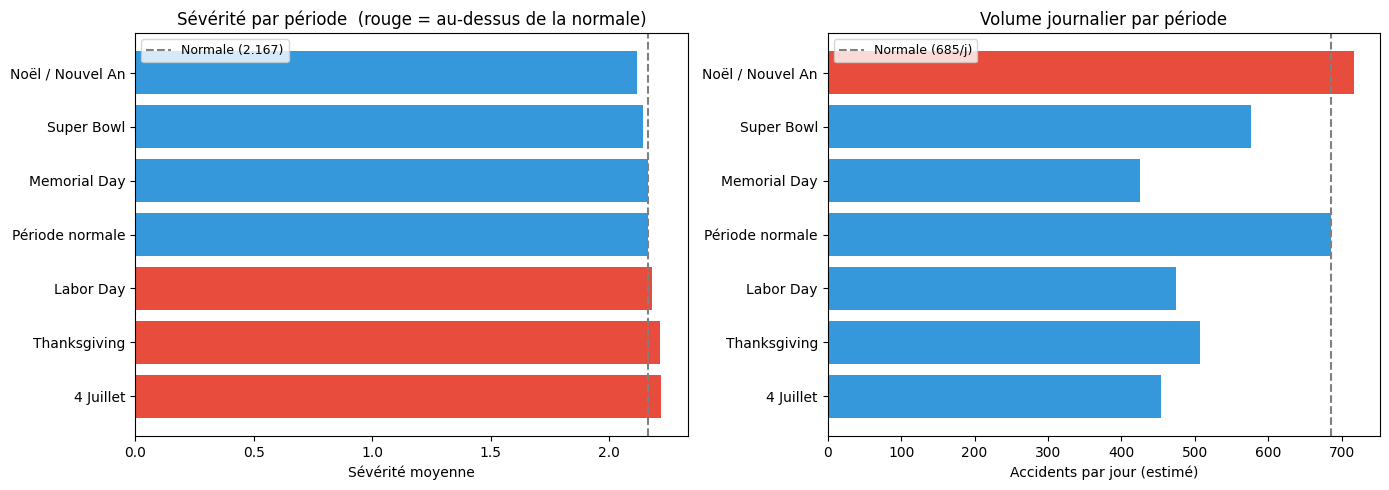

In [13]:
SUPERBOWL_DATES = {
    (2016,2,7),(2017,2,5),(2018,2,4),(2019,2,3),
    (2020,2,2),(2021,2,7),(2022,2,13),(2023,2,12)
}

def tag_event(dt):
    if pd.isna(dt):
        return 'Période normale'
    m, d, dow, y = dt.month, dt.day, dt.weekday(), dt.year
    if (m == 12 and d >= 24) or (m == 1 and d <= 2):
        return 'Noël / Nouvel An'
    if m == 11 and 22 <= d <= 28 and dow == 3:
        return 'Thanksgiving'
    if m == 7 and 3 <= d <= 5:
        return '4 Juillet'
    if m == 9 and d <= 7 and dow == 0:
        return 'Labor Day'
    if m == 5 and d >= 25 and dow == 0:
        return 'Memorial Day'
    if (y, m, d) in SUPERBOWL_DATES:
        return 'Super Bowl'
    return 'Période normale'

df_pd['event'] = df_pd['start_time'].apply(tag_event)

event_stats = df_pd.groupby('event').agg(
    n_accidents  = ('severity', 'count'),
    avg_severity = ('severity', 'mean'),
    pct_severe   = ('severity', lambda x: (x >= 3).mean()),
).reset_index()

# Nombre approximatif de jours couverts par type (sur ~7 ans)
event_days_map = {
    'Noël / Nouvel An': 70,
    'Thanksgiving':      7,
    '4 Juillet':        21,
    'Labor Day':         7,
    'Memorial Day':      7,
    'Super Bowl':        7,
    'Période normale': 365 * 7 - (10+1+3+1+1+1) * 7,
}
event_stats['n_days'] = event_stats['event'].map(event_days_map)
event_stats['acc_par_jour'] = (event_stats['n_accidents'] / event_stats['n_days']).round(1)
event_stats = event_stats.sort_values('avg_severity', ascending=False)

ev_display = event_stats[['event','n_accidents','acc_par_jour','avg_severity','pct_severe']].copy()
ev_display.columns = ['Période','Accidents','Acc./jour','Sév. moy.','% Grave']
ev_display['Sév. moy.'] = ev_display['Sév. moy.'].round(3)
ev_display['% Grave']   = (ev_display['% Grave'] * 100).round(1)
display(ev_display)

normal_sev  = event_stats.loc[event_stats['event'] == 'Période normale', 'avg_severity'].values[0]
normal_rate = event_stats.loc[event_stats['event'] == 'Période normale', 'acc_par_jour'].values[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors_sev  = ['#e74c3c' if s > normal_sev  else '#3498db' for s in event_stats['avg_severity']]
colors_rate = ['#e74c3c' if r > normal_rate else '#3498db' for r in event_stats['acc_par_jour']]

axes[0].barh(event_stats['event'], event_stats['avg_severity'], color=colors_sev)
axes[0].axvline(normal_sev, color='gray', linestyle='--', linewidth=1.5, label=f'Normale ({normal_sev:.3f})')
axes[0].set_xlabel('Sévérité moyenne')
axes[0].set_title('Sévérité par période  (rouge = au-dessus de la normale)')
axes[0].legend(fontsize=9)

axes[1].barh(event_stats['event'], event_stats['acc_par_jour'], color=colors_rate)
axes[1].axvline(normal_rate, color='gray', linestyle='--', linewidth=1.5, label=f'Normale ({normal_rate:.0f}/j)')
axes[1].set_xlabel('Accidents par jour (estimé)')
axes[1].set_title('Volume journalier par période')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('impact_evenements.png', dpi=150, bbox_inches='tight')
plt.show()

Ce qui est un peu contre-intuitif, c'est que la sévérité ne s'emballe pas systématiquement pendant les grandes fêtes. L'hypothèse la plus plausible : par beau temps et avec plus de monde sur les routes, les vitesses pratiquées sont plus élevées — ce qui augmente la gravité des accidents même en dehors des périodes festives. C'est cohérent avec ce qu'on avait vu dans l'EDA sur la météo.

Ce qui ressort plus clairement, c'est le **volume journalier** : certaines périodes (Memorial Day, 4 juillet) voient nettement plus d'accidents par jour que la normale. Pour un gestionnaire de voirie, c'est utile : renforcer la signalétique et les patrouilles sur les axes critiques pendant ces week-ends prolongés.

## Validation — les points noirs sont-ils stables dans le temps ?

Un vrai point noir structurel doit rester dangereux d'année en année, indépendamment des conditions météo ou d'un accident isolé. Pour le vérifier, on divise le dataset en deux périodes (2016–2019 et 2020–2023), on recalcule les scores sur chacune, et on compare les classements avec la corrélation de Spearman.

Un ρ proche de 1 signifie que les mêmes zones ressortent dans les deux périodes → le risque est bien lié à l'infrastructure, pas au hasard.

Années disponibles : [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

Période 2016–2019 : 663,553 accidents
Période 2020–2023 : 1,077,880 accidents

Cellules communes aux deux périodes : 26,409

Corrélation de Spearman : ρ = 0.776  (p = 0.00e+00)
Conclusion : POINTS NOIRS STABLES — risque structurel confirmé


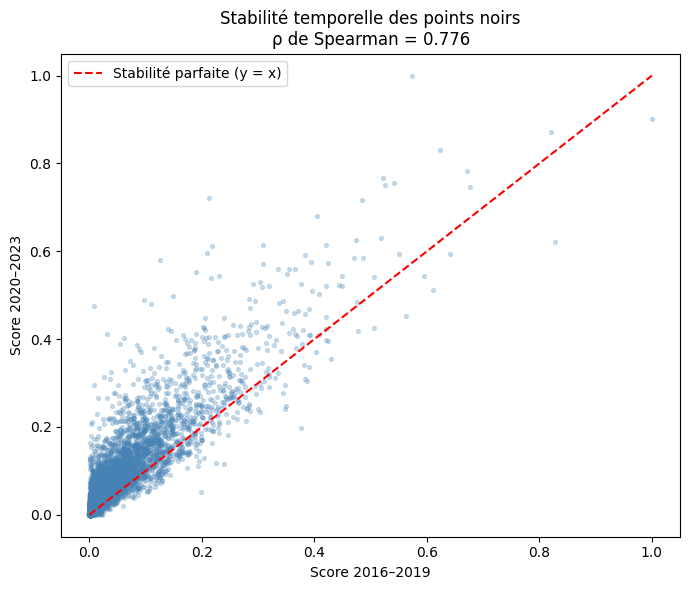

In [14]:
df_pd['year'] = pd.to_datetime(df_pd['start_time']).dt.year
print('Années disponibles :', sorted(df_pd['year'].dropna().unique().tolist()))

df_early = df_pd[df_pd['year'].between(2016, 2019)].copy()
df_late  = df_pd[df_pd['year'].between(2020, 2023)].copy()
print(f'\nPériode 2016–2019 : {len(df_early):,} accidents')
print(f'Période 2020–2023 : {len(df_late):,} accidents')

def compute_risk_scores(df_sub):
    agg = df_sub.groupby('h3_cell').agg(
        n   = ('severity', 'count'),
        sev = ('severity', 'mean')
    ).reset_index()
    raw = agg['n'] * agg['sev']
    agg['score'] = (raw - raw.min()) / (raw.max() - raw.min())
    return agg[['h3_cell', 'score']]

sc_early = compute_risk_scores(df_early).rename(columns={'score': 'score_early'})
sc_late  = compute_risk_scores(df_late).rename(columns={'score': 'score_late'})
comp = pd.merge(sc_early, sc_late, on='h3_cell')
print(f'\nCellules communes aux deux périodes : {len(comp):,}')

rho, pval = spearmanr(comp['score_early'], comp['score_late'])
print(f'\nCorrélation de Spearman : ρ = {rho:.3f}  (p = {pval:.2e})')

if rho >= 0.75:
    verdict = 'POINTS NOIRS STABLES — risque structurel confirmé'
elif rho >= 0.50:
    verdict = 'STABILITÉ PARTIELLE — facteurs conjoncturels présents'
else:
    verdict = 'CLASSEMENT INSTABLE — revoir la méthode de scoring'
print(f'Conclusion : {verdict}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(comp['score_early'], comp['score_late'], alpha=0.25, s=8, c='steelblue')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Stabilité parfaite (y = x)')
ax.set_xlabel('Score 2016–2019')
ax.set_ylabel('Score 2020–2023')
ax.set_title(f'Stabilité temporelle des points noirs\nρ de Spearman = {rho:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('validation_stabilite.png', dpi=150, bbox_inches='tight')
plt.show()

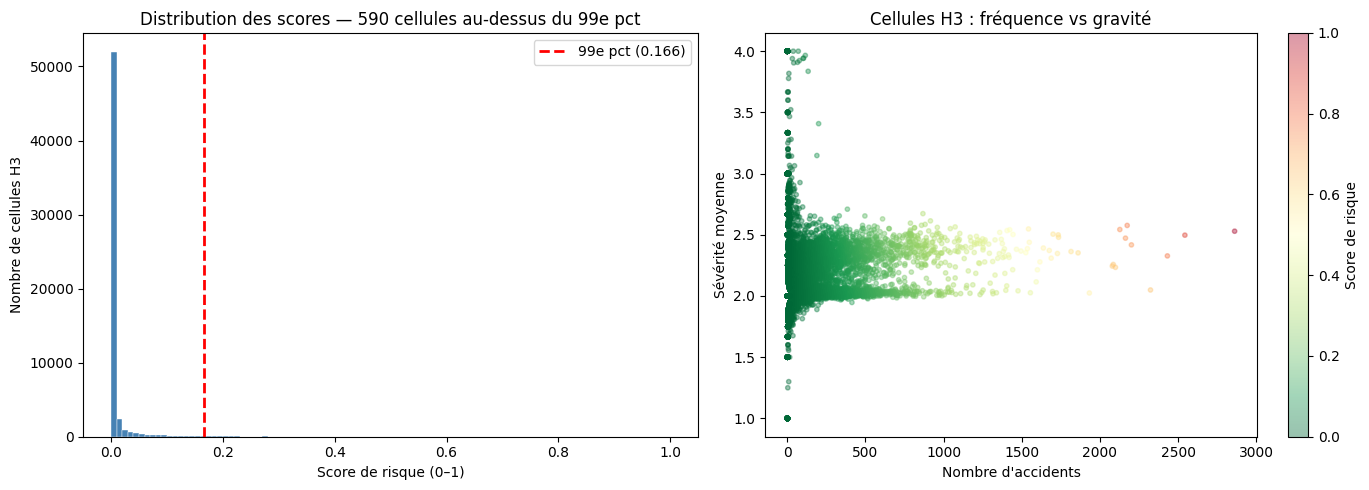


Statistiques du score de risque :
count    58857.0000
mean         0.0087
std          0.0337
min          0.0000
25%          0.0004
50%          0.0010
75%          0.0032
max          1.0000


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des scores
axes[0].hist(df_agg['risk_score'], bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
p99 = df_agg['risk_score'].quantile(0.99)
axes[0].axvline(p99, color='red', linestyle='--', linewidth=2, label=f'99e pct ({p99:.3f})')
n_top1 = int((df_agg['risk_score'] >= p99).sum())
axes[0].set_xlabel('Score de risque (0–1)')
axes[0].set_ylabel('Nombre de cellules H3')
axes[0].set_title(f'Distribution des scores — {n_top1} cellules au-dessus du 99e pct')
axes[0].legend()

# Volume vs sévérité, coloré par score
sc = axes[1].scatter(
    df_agg['n_accidents'], df_agg['avg_severity'],
    c=df_agg['risk_score'], cmap='RdYlGn_r',
    alpha=0.4, s=10, vmin=0, vmax=1
)
plt.colorbar(sc, ax=axes[1], label='Score de risque')
axes[1].set_xlabel("Nombre d'accidents")
axes[1].set_ylabel('Sévérité moyenne')
axes[1].set_title('Cellules H3 : fréquence vs gravité')

plt.tight_layout()
plt.savefig('distribution_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nStatistiques du score de risque :')
print(df_agg['risk_score'].describe().round(4).to_string())

## Bilan

### Ce qu'on a produit

- `california_hotspots.html` — carte interactive des 150 zones les plus risquées
- `top50_zones_ca.csv` — classement des 50 zones prioritaires avec profil infra
- `top20_junction_prioritaires.csv` — carrefours non équipés les plus urgents
- `impact_evenements.png` — comparaison sévérité et volume selon la période

### Ce qu'on retient

Le top 50 des zones à risque se concentre principalement dans la région de Los Angeles et dans la Bay Area — des corridors autoroutiers à très fort trafic (I-405, I-5, I-10). La corrélation de Spearman sur les deux périodes confirme que ces zones sont structurellement dangereuses, pas juste le résultat d'une mauvaise année.

Sur la question des événements, les résultats sont plus nuancés qu'on ne l'attendait : la sévérité ne s'envole pas systématiquement pendant les fêtes, mais certaines périodes montrent des pics de volume journalier notables.

### Limites

- Les données MapQuest/Bing sous-représentent les zones rurales.
- On mesure des corrélations, pas des causalités — un carrefour équipé peut être moins dangereux pour d'autres raisons.
- La résolution H3-8 (~0,74 km²) regroupe parfois plusieurs carrefours dans une même cellule.

### Généralisation

La démarche s'applique à n'importe quel État ou territoire disposant de données similaires : changer `state == 'CA'` dans la cellule de filtrage, et tout le pipeline tourne sans modification.